# Teacher Model Training — ResNet-110 on CIFAR-100

This notebook trains the teacher network used in our knowledge distillation pipeline. We use **ResNet-110** as the teacher — a 110-layer residual network that serves as the performance upper bound for our compression experiments.

The teacher is trained once using standard cross-entropy loss. The final checkpoint is saved to Google Drive and shared across all subsequent notebooks.

**Dataset:** CIFAR-100 — 60,000 images across 100 fine-grained classes (50,000 train / 10,000 test)  
**Architecture:** ResNet-110 (He et al., 2016)  
**Target Accuracy:** ~73% on CIFAR-100 test set

## 1. Mount Google Drive

The trained teacher checkpoint is saved to Google Drive so it remains accessible to all subsequent notebooks regardless of session restarts.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Project folder on Drive — created automatically if it does not exist
DRIVE_BASE  = '/content/drive/MyDrive/kd_project'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Drive mounted.')
print(f'Checkpoints → {CKPT_DIR}')
print(f'Results     → {RESULTS_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Checkpoints → /content/drive/MyDrive/kd_project/checkpoints
Results     → /content/drive/MyDrive/kd_project/results


## 2. Environment Setup

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.')

Device : cuda
GPU    : Tesla T4


## 3. Data Loading and Preprocessing

Training images are augmented with random cropping and horizontal flipping to improve generalization. Test images receive only normalization to ensure consistent evaluation. Normalization statistics are computed from the CIFAR-100 training set.

In [16]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                               download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR100(root='./data', train=False,
                                               download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128,
                                            shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128,
                                            shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')
print(f'Classes       : {len(train_dataset.classes)}')

Train samples : 50,000
Test samples  : 10,000
Classes       : 100


## 4. Model Architecture — ResNet for CIFAR-100

We implement the CIFAR variant of ResNet (He et al., 2016). The core innovation is the **residual (skip) connection** — each block adds its input directly to its output, enabling clean gradient flow through very deep networks and preventing the accuracy degradation observed in plain deep networks.

Network depth is controlled by the number of BasicBlocks per stage:
- **ResNet-110:** `[18, 18, 18]` blocks → 110 layers, ~1.7M parameters (teacher)
- **ResNet-20:** `[3, 3, 3]` blocks → 20 layers, ~0.27M parameters (student)

Both architectures are defined here and reused across all distillation notebooks.

In [17]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                  stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                  stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNet_CIFAR, self).__init__()
        self.in_channels = 16
        self.conv1       = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1         = nn.BatchNorm2d(16)
        self.relu        = nn.ReLU(inplace=True)
        self.layer1      = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2      = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3      = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool     = nn.AdaptiveAvgPool2d((1, 1))
        self.fc          = nn.Linear(64 * block.expansion, num_classes)
        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def ResNet110(num_classes=100):
    return ResNet_CIFAR(BasicBlock, [18, 18, 18], num_classes)

def ResNet20(num_classes=100):
    return ResNet_CIFAR(BasicBlock, [3, 3, 3], num_classes)


teacher      = ResNet110(num_classes=100).to(device)
total_params = sum(p.numel() for p in teacher.parameters())
print(f'ResNet-110 initialized — {total_params:,} parameters ({total_params/1e6:.2f}M)')

ResNet-110 initialized — 1,736,564 parameters (1.74M)


## 5. Training Configuration

We follow the standard training protocol for CIFAR ResNets (He et al., 2016):
- **Optimizer:** SGD with Nesterov momentum
- **Initial LR:** 0.1, decayed by ×0.1 at epochs 100 and 150
- **Weight decay:** 5×10⁻⁴
- **Epochs:** 200

In [18]:
NUM_EPOCHS    = 100
LEARNING_RATE = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(teacher.parameters(), lr=LEARNING_RATE,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)

print(f'Optimizer  : SGD with Nesterov momentum')
print(f'Epochs     : {NUM_EPOCHS}')
print(f'LR schedule: 0.1 → 0.01 (epoch 50) → 0.001 (epoch 75)')

Optimizer  : SGD with Nesterov momentum
Epochs     : 100
LR schedule: 0.1 → 0.01 (epoch 50) → 0.001 (epoch 75)


## 6. Training and Evaluation Functions

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits         = model(images)
            loss           = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


print('Functions defined.')

Functions defined.


## 7. Training Loop

The model is trained for 200 epochs. The best checkpoint by test accuracy is saved to Google Drive and used in all distillation experiments.

In [20]:
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc  = 0.0
CKPT_PATH = f'{CKPT_DIR}/teacher_resnet110.pth'

print(f'Training ResNet-110 on {device} for {NUM_EPOCHS} epochs...')
print('=' * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(teacher, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(teacher, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss);  test_losses.append(test_loss)
    train_accs.append(train_acc);     test_accs.append(test_acc)

    # Save to Drive whenever test accuracy improves
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(teacher.state_dict(), CKPT_PATH)

    elapsed    = (time.time() - start_time) / 60
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
          f'Test Acc: {test_acc:.2f}%  Best: {best_acc:.2f}%  '
          f'LR: {current_lr:.4f}  Elapsed: {elapsed:.1f}m')

elapsed = (time.time() - start_time) / 60
print('=' * 70)
print(f'Training complete — Best Test Accuracy: {best_acc:.2f}% — Total time: {elapsed:.1f} min')
print(f'Checkpoint saved to: {CKPT_PATH}')

Training ResNet-110 on cuda for 100 epochs...
Epoch [  1/100]  Train Loss: 4.5737  Train Acc: 1.67%  Test Acc: 2.95%  Best: 2.95%  LR: 0.1000  Elapsed: 1.4m
Epoch [  2/100]  Train Loss: 4.0946  Train Acc: 6.38%  Test Acc: 11.19%  Best: 11.19%  LR: 0.1000  Elapsed: 2.8m
Epoch [  3/100]  Train Loss: 3.4471  Train Acc: 16.00%  Test Acc: 17.45%  Best: 17.45%  LR: 0.1000  Elapsed: 4.3m
Epoch [  4/100]  Train Loss: 2.9102  Train Acc: 25.72%  Test Acc: 25.96%  Best: 25.96%  LR: 0.1000  Elapsed: 5.7m
Epoch [  5/100]  Train Loss: 2.5368  Train Acc: 33.40%  Test Acc: 31.53%  Best: 31.53%  LR: 0.1000  Elapsed: 7.1m
Epoch [  6/100]  Train Loss: 2.2848  Train Acc: 38.89%  Test Acc: 33.00%  Best: 33.00%  LR: 0.1000  Elapsed: 8.5m
Epoch [  7/100]  Train Loss: 2.1041  Train Acc: 43.18%  Test Acc: 38.72%  Best: 38.72%  LR: 0.1000  Elapsed: 9.9m
Epoch [  8/100]  Train Loss: 1.9748  Train Acc: 45.84%  Test Acc: 37.69%  Best: 38.72%  LR: 0.1000  Elapsed: 11.4m
Epoch [  9/100]  Train Loss: 1.8777  Train Ac

## 8. Training Curves

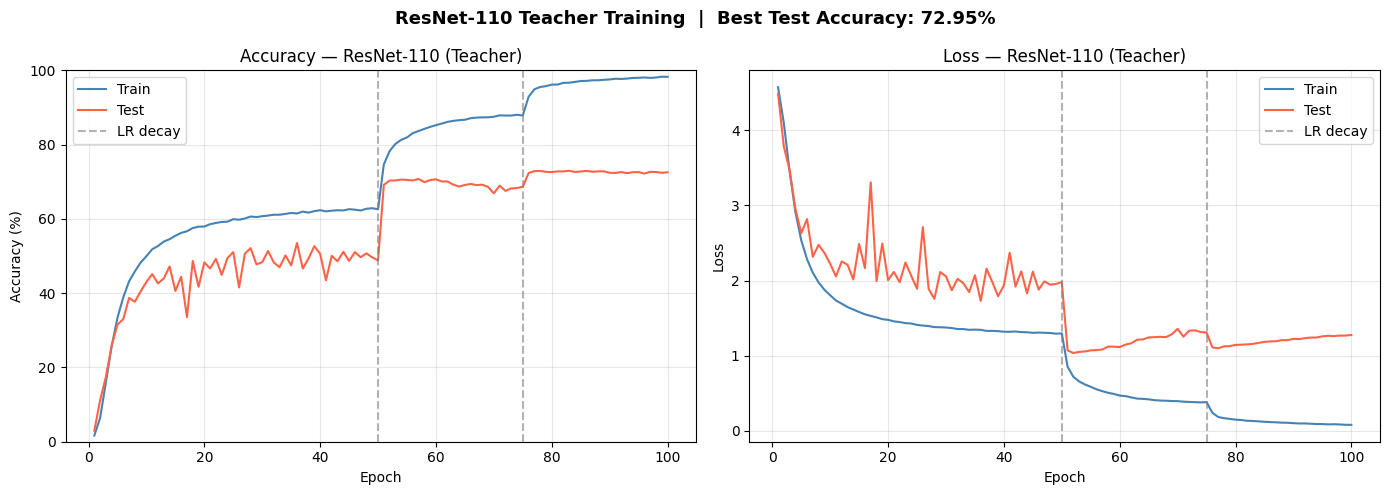

Plot saved to Drive.


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range    = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_accs, label='Train', color='steelblue', linewidth=1.5)
ax1.plot(epochs_range, test_accs,  label='Test',  color='tomato',    linewidth=1.5)
ax1.axvline(x=50, color='gray', linestyle='--', alpha=0.6, label='LR decay')
ax1.axvline(x=75, color='gray', linestyle='--', alpha=0.6)
ax1.set_xlabel('Epoch');  ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy — ResNet-110 (Teacher)')
ax1.legend();  ax1.grid(True, alpha=0.3);  ax1.set_ylim([0, 100])

ax2.plot(epochs_range, train_losses, label='Train', color='steelblue', linewidth=1.5)
ax2.plot(epochs_range, test_losses,  label='Test',  color='tomato',    linewidth=1.5)
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.6, label='LR decay')
ax2.axvline(x=75, color='gray', linestyle='--', alpha=0.6)
ax2.set_xlabel('Epoch');  ax2.set_ylabel('Loss')
ax2.set_title('Loss — ResNet-110 (Teacher)')
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.suptitle(f'ResNet-110 Teacher Training  |  Best Test Accuracy: {best_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/teacher_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to Drive.')

## 9. Final Evaluation

The best checkpoint is reloaded and evaluated on the test set. This accuracy represents the performance ceiling that all distilled student models are benchmarked against.

In [24]:
best_teacher = ResNet110(num_classes=100).to(device)
best_teacher.load_state_dict(torch.load(CKPT_PATH, map_location=device))

_, final_acc = evaluate(best_teacher, test_loader, criterion, device)
total_params  = sum(p.numel() for p in best_teacher.parameters())

print('=' * 45)
print('  ResNet-110 Teacher — Final Results')
print('=' * 45)
print(f'  Test Accuracy : {final_acc:.2f}%')
print(f'  Parameters    : {total_params/1e6:.2f}M')
print(f'  Checkpoint    : {CKPT_PATH}')
print('=' * 45)

  ResNet-110 Teacher — Final Results
  Test Accuracy : 72.95%
  Parameters    : 1.74M
  Checkpoint    : /content/drive/MyDrive/kd_project/checkpoints/teacher_resnet110.pth
